# FraudNet — Exploration des comptes synthétiques
Analyse du fichier `data/generated/accounts.parquet` généré par `profile_generator.py`.

In [1]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted", font_scale=1.1)
PALETTE = sns.color_palette("tab10")

DATA = Path("../data/generated/accounts.parquet")
df = pd.read_parquet(DATA)

# Colonnes list/dict stockées en string → on les reparse
df["devices_list"]       = df["devices"].str.split("|")
df["commercants_list"]   = df["commercants_habituels"].str.split("|")
df["categories_dict"]    = df["categories_depenses"].apply(ast.literal_eval)
df["horaires_dict"]      = df["horaires_actifs"].apply(ast.literal_eval)
df["date_ouverture"]     = pd.to_datetime(df["date_ouverture"])

print(f"Comptes chargés : {len(df):,}")
df.head(3)

Comptes chargés : 1,000


,account_id,archetype,prenom,nom,email,telephone,date_naissance,ville,province,code_postal,...,categories_depenses,horaires_actifs,commercants_habituels,date_ouverture,solde_initial,est_vulnerabilite,devices_list,commercants_list,categories_dict,horaires_dict
0,b712e299-110b-487c-a730-ccfd2be2ae7f,jeune_actif,Colette,Gingras,gendroncolette@example.net,7412454563,1956-10-15,Vancouver,BC,B5N 8J5,...,"{'epicerie': 0.2, 'restauration': 0.2, 'voyage...","{'jours_semaine': [7, 8, 12, 18, 19, 20], 'wee...",Metro|Super C|Subway|Virement e-Transfer|McDon...,2023-05-16,19857.85,False,"[desktop, mobile]","[Metro, Super C, Subway, Virement e-Transfer, ...","{'epicerie': 0.2, 'restauration': 0.2, 'voyage...","{'jours_semaine': [7, 8, 12, 18, 19, 20], 'wee..."
1,7c880880-37c6-47a9-a505-dc89db20a25c,jeune_actif,Valérie,Daigle,noellaroche@example.net,(504)810-2767x478,1988-05-26,Toronto,ON,V9L7G1,...,"{'epicerie': 0.2, 'restauration': 0.2, 'voyage...","{'jours_semaine': [7, 8, 12, 18, 19, 20], 'wee...",Videotron|Epic Games|Netflix|St-Hubert|Air Tra...,2018-05-06,16133.65,False,"[tablette, desktop]","[Videotron, Epic Games, Netflix, St-Hubert, Ai...","{'epicerie': 0.2, 'restauration': 0.2, 'voyage...","{'jours_semaine': [7, 8, 12, 18, 19, 20], 'wee..."
2,678fcc16-1dbf-4a1e-8433-017d3ef90afb,famille,Mathieu,Patel,louise51@example.com,646.282.3948,1999-03-08,Ottawa,ON,V1K 9A7,...,"{'epicerie': 0.35, 'sante': 0.15, 'education':...","{'jours_semaine': [8, 9, 12, 17, 18, 19], 'wee...",Metro|Registraire|McDonald's|Rona|Loblaws|H&M|...,2021-05-27,23722.22,False,[desktop],"[Metro, Registraire, McDonald's, Rona, Loblaws...","{'epicerie': 0.35, 'sante': 0.15, 'education':...","{'jours_semaine': [8, 9, 12, 17, 18, 19], 'wee..."


## 1. Vue d'ensemble — shape & types

In [2]:
print(f"Dimensions : {df.shape}")
print(f"\nTypes :\n{df.dtypes.to_string()}")
print(f"\nValeurs manquantes :\n{df.isnull().sum()[df.isnull().sum() > 0].to_string() or 'Aucune'}")

Dimensions : (1000, 25)

Types :
account_id                              str
archetype                               str
prenom                                  str
nom                                     str
email                                   str
telephone                               str
date_naissance                          str
ville                                   str
province                                str
code_postal                             str
revenu_mensuel                      float64
montant_moyen_transaction           float64
frequence_hebdo                       int64
devices                                 str
device_principal                        str
categories_depenses                     str
horaires_actifs                         str
commercants_habituels                   str
date_ouverture               datetime64[us]
solde_initial                       float64
est_vulnerabilite                      bool
devices_list                         object

In [3]:
df[["revenu_mensuel", "montant_moyen_transaction", "frequence_hebdo", "solde_initial"]].describe().round(2)

,revenu_mensuel,montant_moyen_transaction,frequence_hebdo,solde_initial
count,1000.00,1000.00,1000.00,1000.00
mean,8662.31,193.66,18.13,22565.97
std,12451.35,320.24,12.28,35967.72
min,977.02,5.00,3.00,1645.27
25%,2957.74,46.53,10.00,6251.36
50%,4545.27,80.22,15.00,11228.37
75%,7992.50,126.06,23.00,20833.39
max,75000.00,1788.36,60.00,299572.79


## 2. Répartition des archétypes

/var/folders/0r/yccbt2rs1p72w8f7g0zfj8dc0000gn/T/ipykernel_29740/853695249.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="tab10", ax=axes[1])


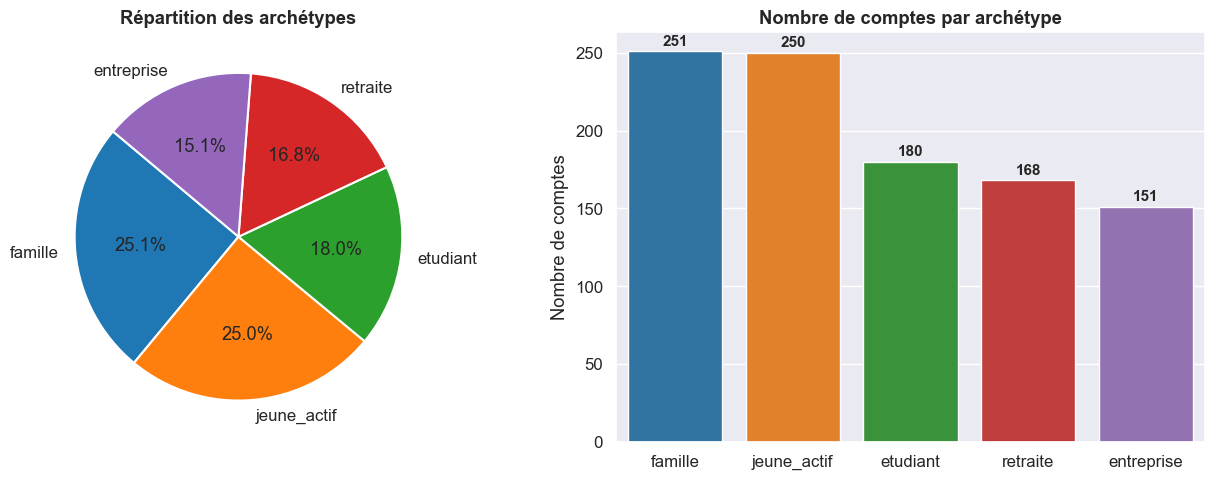

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df["archetype"].value_counts()

# Camembert
axes[0].pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
    colors=PALETTE[:len(counts)],
    startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=1.5),
)
axes[0].set_title("Répartition des archétypes", fontweight="bold")

# Barres
sns.barplot(x=counts.index, y=counts.values, palette="tab10", ax=axes[1])
axes[1].set_title("Nombre de comptes par archétype", fontweight="bold")
axes[1].set_ylabel("Nombre de comptes")
axes[1].set_xlabel("")
for bar, v in zip(axes[1].patches, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(v),
                 ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

## 3. Distribution des revenus mensuels

/var/folders/0r/yccbt2rs1p72w8f7g0zfj8dc0000gn/T/ipykernel_29740/2297752730.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


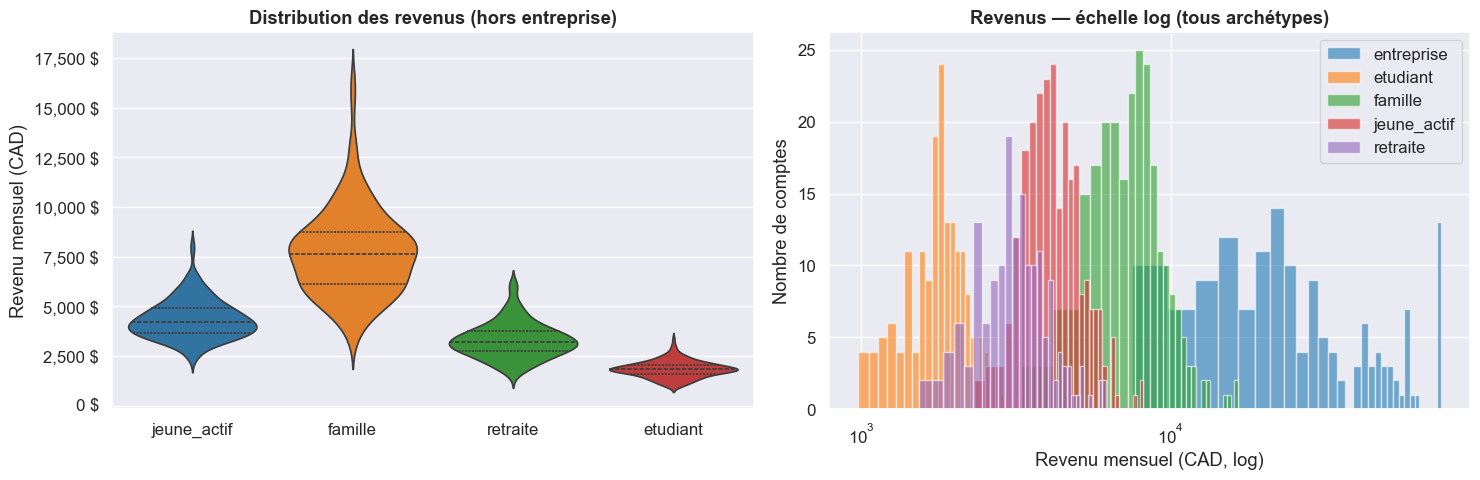

,mean,50%,min,max
archetype,,,,
entreprise,31480.0,25005.0,7500.0,75000.0
etudiant,1834.0,1819.0,977.0,3364.0
famille,7715.0,7623.0,3296.0,16510.0
jeune_actif,4350.0,4207.0,2319.0,8164.0
retraite,3302.0,3213.0,1533.0,6175.0


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Violon par archétype
sns.violinplot(
    data=df[df["archetype"] != "entreprise"],  # exclure entreprise pour l'échelle
    x="archetype", y="revenu_mensuel",
    palette="tab10", inner="quartile", ax=axes[0]
)
axes[0].set_title("Distribution des revenus (hors entreprise)", fontweight="bold")
axes[0].set_ylabel("Revenu mensuel (CAD)")
axes[0].set_xlabel("")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f} $"))

# Histogramme log-scale avec tous les archétypes
for i, (arch, grp) in enumerate(df.groupby("archetype")):
    axes[1].hist(grp["revenu_mensuel"], bins=30, alpha=0.6,
                 label=arch, color=PALETTE[i], edgecolor="white")
axes[1].set_xscale("log")
axes[1].set_title("Revenus — échelle log (tous archétypes)", fontweight="bold")
axes[1].set_xlabel("Revenu mensuel (CAD, log)")
axes[1].set_ylabel("Nombre de comptes")
axes[1].legend()

plt.tight_layout()
plt.show()

df.groupby("archetype")["revenu_mensuel"].describe()[["mean","50%","min","max"]].round(0)

## 4. Montant moyen par transaction & fréquence hebdomadaire

/var/folders/0r/yccbt2rs1p72w8f7g0zfj8dc0000gn/T/ipykernel_29740/3717888085.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


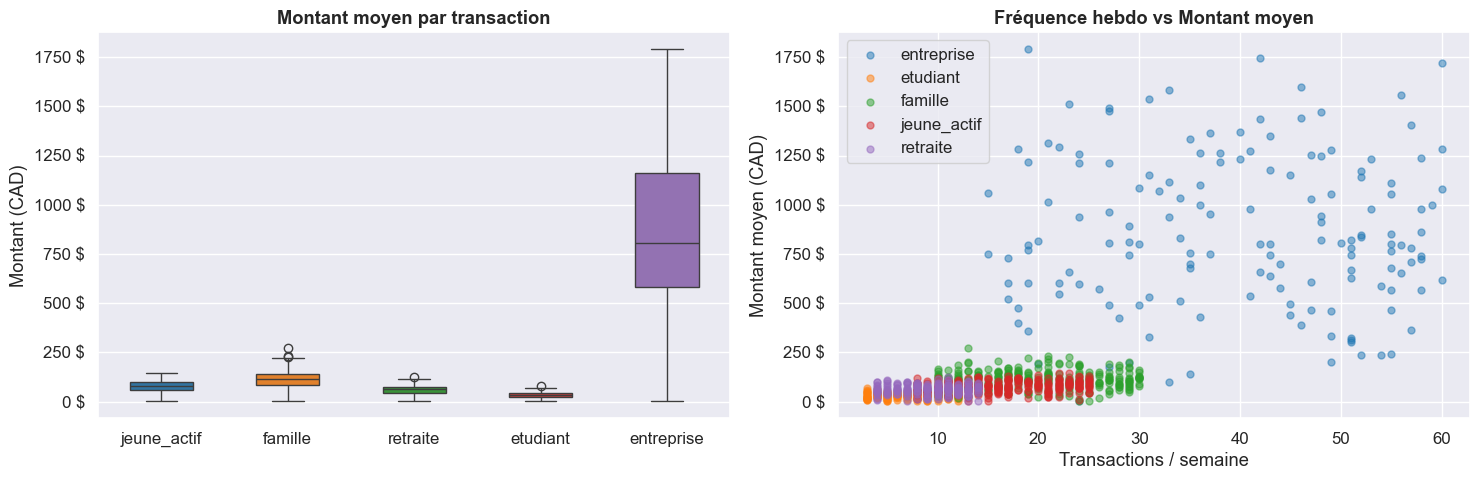

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot montants
sns.boxplot(
    data=df, x="archetype", y="montant_moyen_transaction",
    palette="tab10", width=0.5, ax=axes[0]
)
axes[0].set_title("Montant moyen par transaction", fontweight="bold")
axes[0].set_ylabel("Montant (CAD)")
axes[0].set_xlabel("")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f} $"))

# Scatter fréquence vs montant, coloré par archétype
for i, (arch, grp) in enumerate(df.groupby("archetype")):
    axes[1].scatter(
        grp["frequence_hebdo"], grp["montant_moyen_transaction"],
        label=arch, alpha=0.5, s=25, color=PALETTE[i]
    )
axes[1].set_title("Fréquence hebdo vs Montant moyen", fontweight="bold")
axes[1].set_xlabel("Transactions / semaine")
axes[1].set_ylabel("Montant moyen (CAD)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f} $"))
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Distribution géographique

/var/folders/0r/yccbt2rs1p72w8f7g0zfj8dc0000gn/T/ipykernel_29740/1123193018.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ville_counts.index, y=ville_counts.values, palette="Blues_d", ax=axes[0])


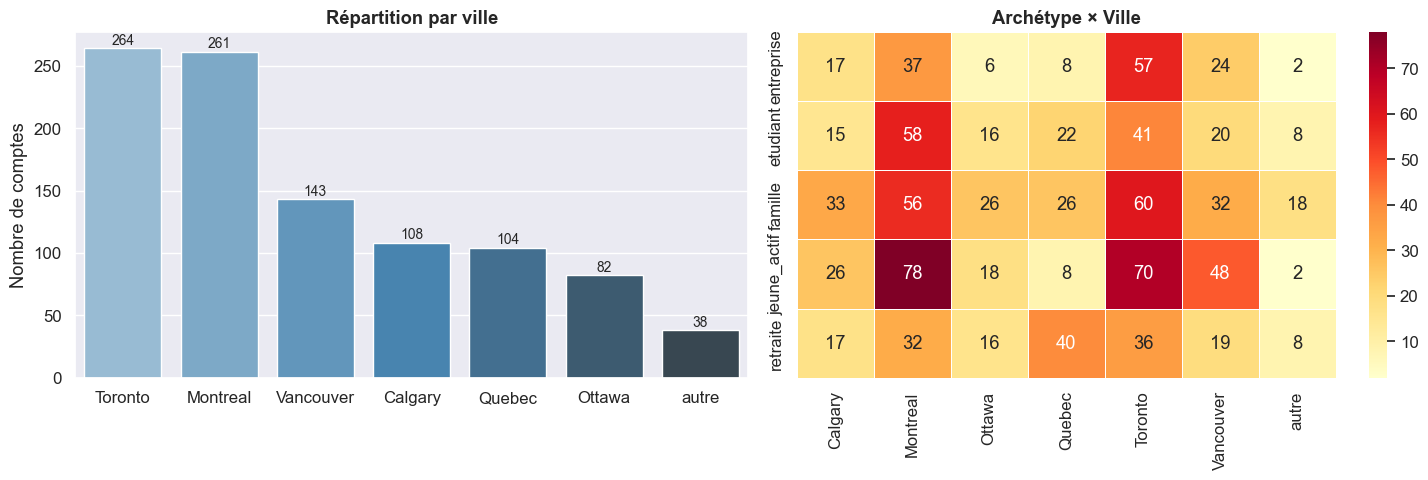

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Comptes par ville
ville_counts = df["ville"].value_counts()
sns.barplot(x=ville_counts.index, y=ville_counts.values, palette="Blues_d", ax=axes[0])
axes[0].set_title("Répartition par ville", fontweight="bold")
axes[0].set_ylabel("Nombre de comptes")
axes[0].set_xlabel("")
for bar, v in zip(axes[0].patches, ville_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(v),
                 ha="center", va="bottom", fontsize=10)

# Heatmap archétype × ville
heatmap_data = df.groupby(["archetype", "ville"]).size().unstack(fill_value=0)
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlOrRd",
            linewidths=0.5, ax=axes[1])
axes[1].set_title("Archétype × Ville", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 6. Devices enregistrés

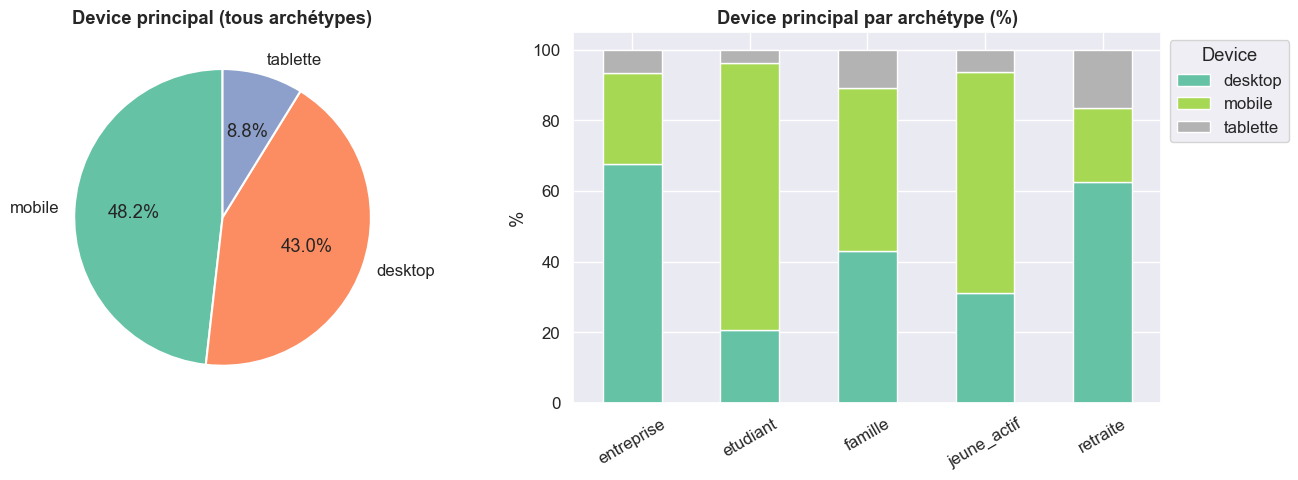

Comptes avec 2 devices enregistrés : 396


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Device principal
dp = df["device_principal"].value_counts()
axes[0].pie(dp.values, labels=dp.index, autopct="%1.1f%%",
            colors=sns.color_palette("Set2"), startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[0].set_title("Device principal (tous archétypes)", fontweight="bold")

# Device principal par archétype
device_arch = df.groupby(["archetype", "device_principal"]).size().unstack(fill_value=0)
device_arch_pct = device_arch.div(device_arch.sum(axis=1), axis=0) * 100
device_arch_pct.plot(kind="bar", stacked=True, colormap="Set2",
                     ax=axes[1], edgecolor="white")
axes[1].set_title("Device principal par archétype (%)", fontweight="bold")
axes[1].set_ylabel("%")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Device", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

print("Comptes avec 2 devices enregistrés :",
      df["devices_list"].apply(len).eq(2).sum())

## 7. Catégories de dépenses par archétype

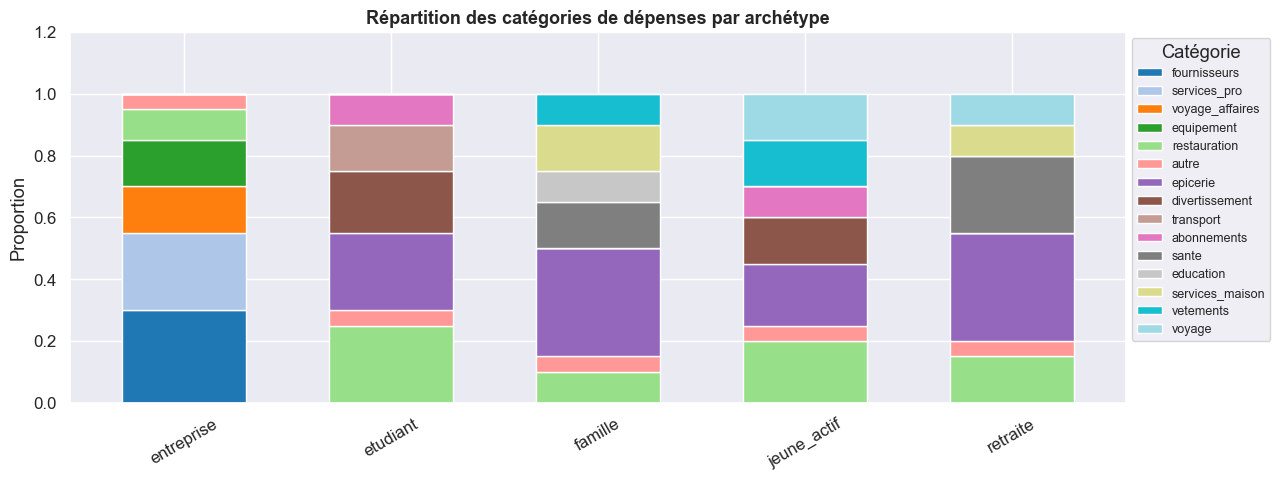

,fournisseurs,services_pro,voyage_affaires,equipement,restauration,autre,epicerie,divertissement,transport,abonnements,sante,education,services_maison,vetements,voyage
entreprise,0.3,0.25,0.15,0.15,0.10,0.05,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00
etudiant,0.0,0.00,0.00,0.00,0.25,0.05,0.25,0.20,0.15,0.1,0.00,0.0,0.00,0.00,0.00
famille,0.0,0.00,0.00,0.00,0.10,0.05,0.35,0.00,0.00,0.0,0.15,0.1,0.15,0.10,0.00
jeune_actif,0.0,0.00,0.00,0.00,0.20,0.05,0.20,0.15,0.00,0.1,0.00,0.0,0.00,0.15,0.15
retraite,0.0,0.00,0.00,0.00,0.15,0.05,0.35,0.00,0.00,0.0,0.25,0.0,0.10,0.00,0.10


In [9]:
# Extraire les catégories par archétype (une ligne par archétype suffit car c'est identique dans le profil)
arch_cats = {}
for arch, grp in df.groupby("archetype"):
    arch_cats[arch] = grp.iloc[0]["categories_dict"]

cats_df = pd.DataFrame(arch_cats).T.fillna(0)

fig, ax = plt.subplots(figsize=(13, 5))
cats_df.plot(kind="bar", stacked=True, colormap="tab20", ax=ax, edgecolor="white", width=0.6)
ax.set_title("Répartition des catégories de dépenses par archétype", fontweight="bold", fontsize=13)
ax.set_ylabel("Proportion")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=30)
ax.set_ylim(0, 1.2)
ax.legend(title="Catégorie", bbox_to_anchor=(1, 1), fontsize=9)
plt.tight_layout()
plt.show()

cats_df.round(2)

## 8. Horaires d'activité

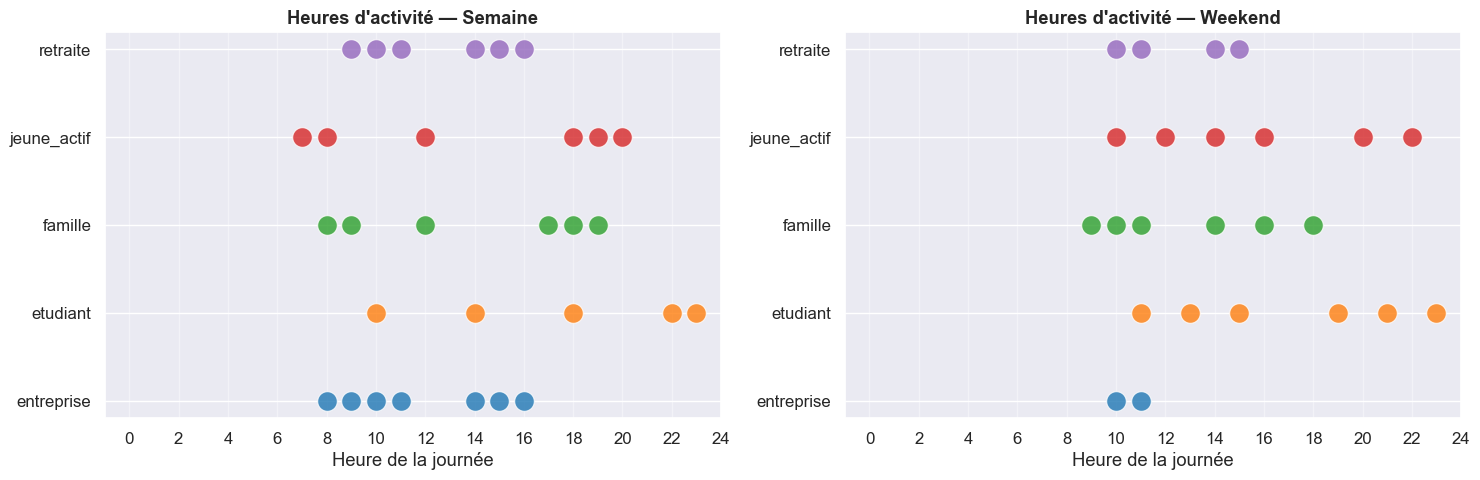

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for idx, day_type in enumerate(["jours_semaine", "weekend"]):
    ax = axes[idx]
    for i, (arch, grp) in enumerate(df.groupby("archetype")):
        heures = grp.iloc[0]["horaires_dict"][day_type]
        ax.scatter(heures, [arch] * len(heures),
                   s=200, color=PALETTE[i], alpha=0.8, edgecolors="white", linewidths=0.8)
    ax.set_xlim(-1, 24)
    ax.set_xticks(range(0, 25, 2))
    ax.set_xlabel("Heure de la journée")
    title = "Semaine" if day_type == "jours_semaine" else "Weekend"
    ax.set_title(f"Heures d'activité — {title}", fontweight="bold")
    ax.grid(axis="x", alpha=0.4)

plt.tight_layout()
plt.show()

## 9. Ancienneté des comptes & solde initial

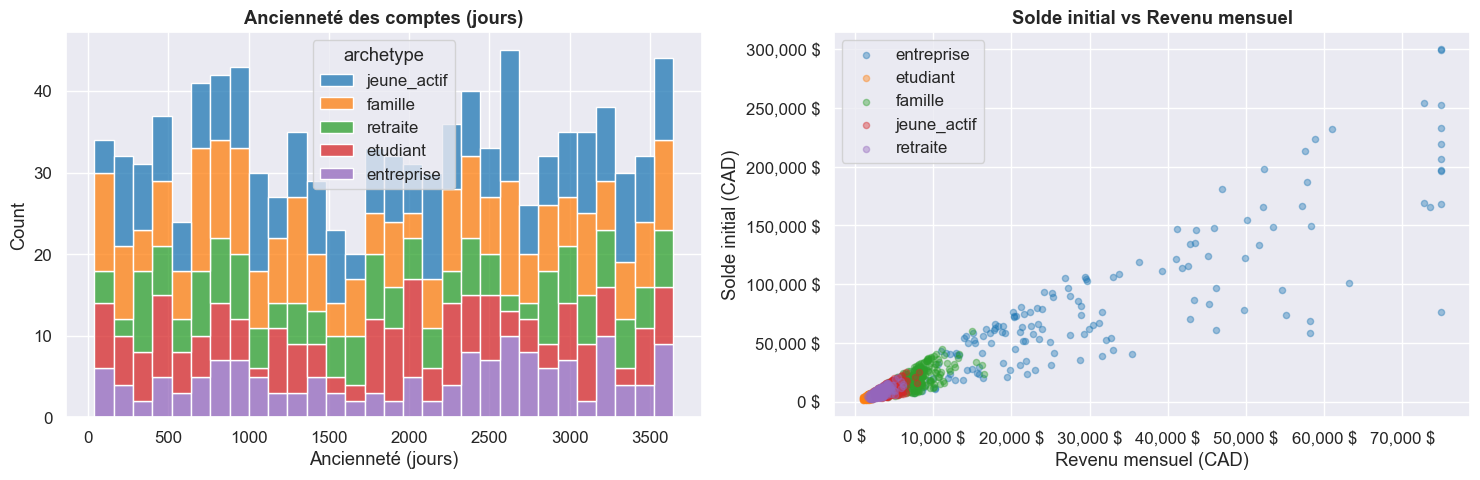

In [11]:
df["anciennete_jours"] = (pd.Timestamp.today().normalize() - df["date_ouverture"]).dt.days

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogramme ancienneté
sns.histplot(data=df, x="anciennete_jours", hue="archetype",
             bins=30, multiple="stack", palette="tab10", ax=axes[0])
axes[0].set_title("Ancienneté des comptes (jours)", fontweight="bold")
axes[0].set_xlabel("Ancienneté (jours)")

# Scatter solde vs revenu
for i, (arch, grp) in enumerate(df.groupby("archetype")):
    axes[1].scatter(grp["revenu_mensuel"], grp["solde_initial"],
                    label=arch, alpha=0.4, s=20, color=PALETTE[i])
axes[1].set_title("Solde initial vs Revenu mensuel", fontweight="bold")
axes[1].set_xlabel("Revenu mensuel (CAD)")
axes[1].set_ylabel("Solde initial (CAD)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f} $"))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f} $"))
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Profils vulnérables (cibles de fraude futures)

Comptes vulnérables : 55 (5.5%)


/var/folders/0r/yccbt2rs1p72w8f7g0zfj8dc0000gn/T/ipykernel_29740/1924001502.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vuln_counts.index, y=vuln_counts.values, palette="Reds_d", ax=axes[0])
/var/folders/0r/yccbt2rs1p72w8f7g0zfj8dc0000gn/T/ipykernel_29740/1924001502.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="statut", y="revenu_mensuel", palette={"Vulnérable": "#e74c3c", "Normal": "#3498db"}, ax=axes[1])


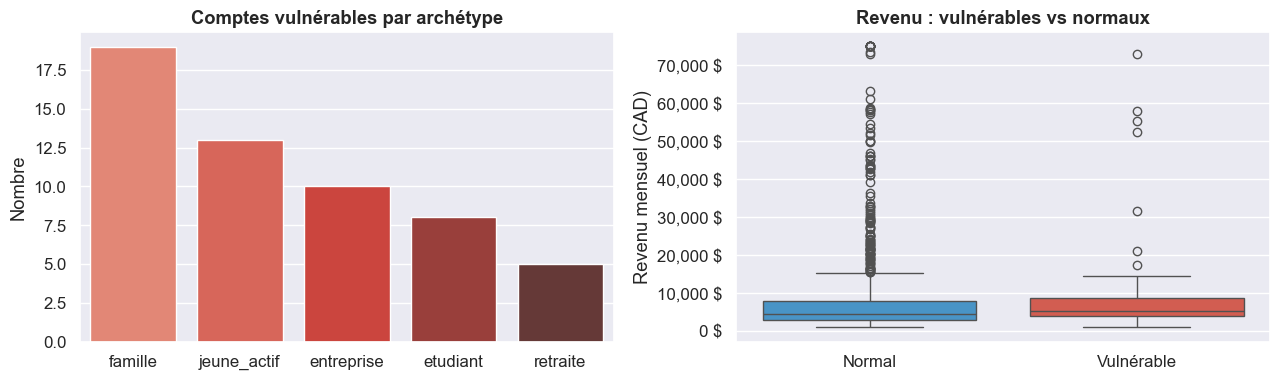

In [12]:
vuln = df[df["est_vulnerabilite"]]
print(f"Comptes vulnérables : {len(vuln)} ({len(vuln)/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Répartition par archétype
vuln_counts = vuln["archetype"].value_counts()
sns.barplot(x=vuln_counts.index, y=vuln_counts.values, palette="Reds_d", ax=axes[0])
axes[0].set_title("Comptes vulnérables par archétype", fontweight="bold")
axes[0].set_ylabel("Nombre")
axes[0].set_xlabel("")

# Comparaison revenu : vulnérables vs non-vulnérables
df["statut"] = df["est_vulnerabilite"].map({True: "Vulnérable", False: "Normal"})
sns.boxplot(data=df, x="statut", y="revenu_mensuel", palette={"Vulnérable": "#e74c3c", "Normal": "#3498db"}, ax=axes[1])
axes[1].set_title("Revenu : vulnérables vs normaux", fontweight="bold")
axes[1].set_ylabel("Revenu mensuel (CAD)")
axes[1].set_xlabel("")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f} $"))

plt.tight_layout()
plt.show()

## 11. Matrice de corrélation — variables numériques

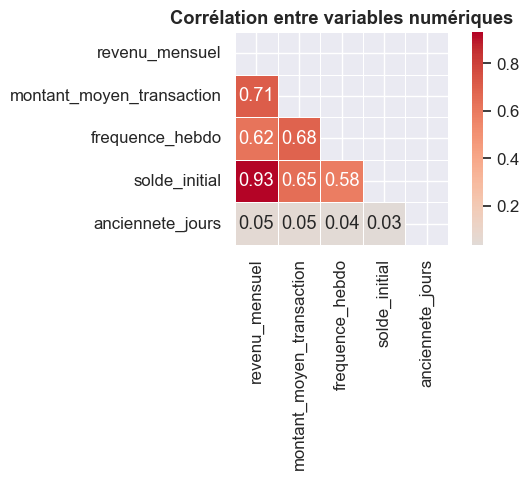

In [13]:
num_cols = ["revenu_mensuel", "montant_moyen_transaction", "frequence_hebdo",
            "solde_initial", "anciennete_jours"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Corrélation entre variables numériques", fontweight="bold")
plt.tight_layout()
plt.show()

## 12. Résumé — ce qu'on a en main

In [14]:
print("=" * 55)
print("RÉSUMÉ DU PORTEFEUILLE SYNTHÉTIQUE")
print("=" * 55)
print(f"  Comptes total            : {len(df):,}")
print(f"  Archétypes               : {df['archetype'].nunique()}")
print(f"  Villes couvertes         : {df['ville'].nunique()}")
print(f"  Provinces couvertes      : {df['province'].nunique()}")
print(f"  Revenu médian (CAD/mois) : {df['revenu_mensuel'].median():,.0f} $")
print(f"  Montant médian/transaction: {df['montant_moyen_transaction'].median():,.0f} $")
print(f"  Fréquence médiane/semaine: {df['frequence_hebdo'].median():.0f} tx")
print(f"  Comptes vulnérables      : {df['est_vulnerabilite'].sum()} ({df['est_vulnerabilite'].mean()*100:.1f}%)")
print(f"  Comptes avec 2 devices   : {df['devices_list'].apply(len).eq(2).sum()}")
print("=" * 55)
print("\nProchaine étape : transaction_engine.py")
print("→ Générer un flux de transactions cohérent avec ces profils")

RÉSUMÉ DU PORTEFEUILLE SYNTHÉTIQUE
  Comptes total            : 1,000
  Archétypes               : 5
  Villes couvertes         : 7
  Provinces couvertes      : 4
  Revenu médian (CAD/mois) : 4,545 $
  Montant médian/transaction: 80 $
  Fréquence médiane/semaine: 15 tx
  Comptes vulnérables      : 55 (5.5%)
  Comptes avec 2 devices   : 396

Prochaine étape : transaction_engine.py
→ Générer un flux de transactions cohérent avec ces profils
